# 5. Advanced EDA

Visual validation of findings from the SQL analysis. Three perspectives: score distributions per app, time trends, and topic patterns.

This notebook complements `04_sql_analysis.ipynb` by showing the data visually rather than as tables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import sqlite3
from pathlib import Path

# SQLite connection. The repo ships with the populated DB.
DB_PATH = Path("..") / "data" / "processed" / "reviews.db"
engine = sqlite3.connect(DB_PATH)

reviews = pd.read_sql("""
SELECT 
    r.review_id, r.app_id, r.score, r.review_date,
    a.name, a.segment
FROM reviews r
INNER JOIN apps a ON r.app_id = a.app_id
WHERE r.score IS NOT NULL
""", engine)
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
print(f"Loaded {len(reviews):,} reviews across {reviews['name'].nunique()} apps")

Loaded 47,187 reviews across 11 apps


## 5.1 Score Distributions

Are user reviews polarized? Do app averages mask bimodal patterns?

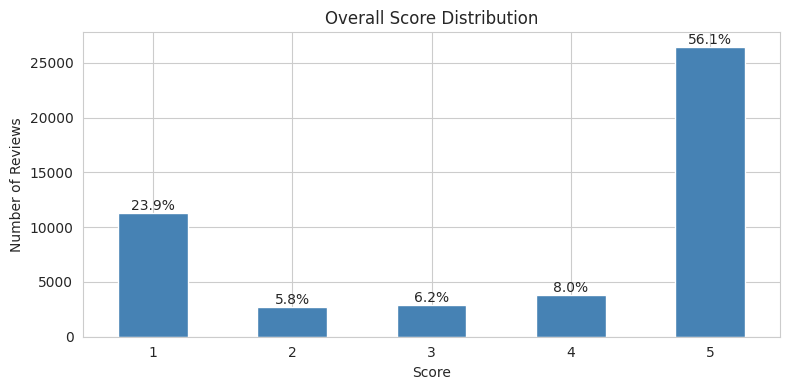

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
score_counts = reviews['score'].value_counts().sort_index()
score_counts.plot(kind='bar', ax=ax, color='steelblue')
total = score_counts.sum()
for i, v in enumerate(score_counts):
    ax.text(i, v, f"{v/total*100:.1f}%", ha='center', va='bottom')
ax.set_title('Overall Score Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

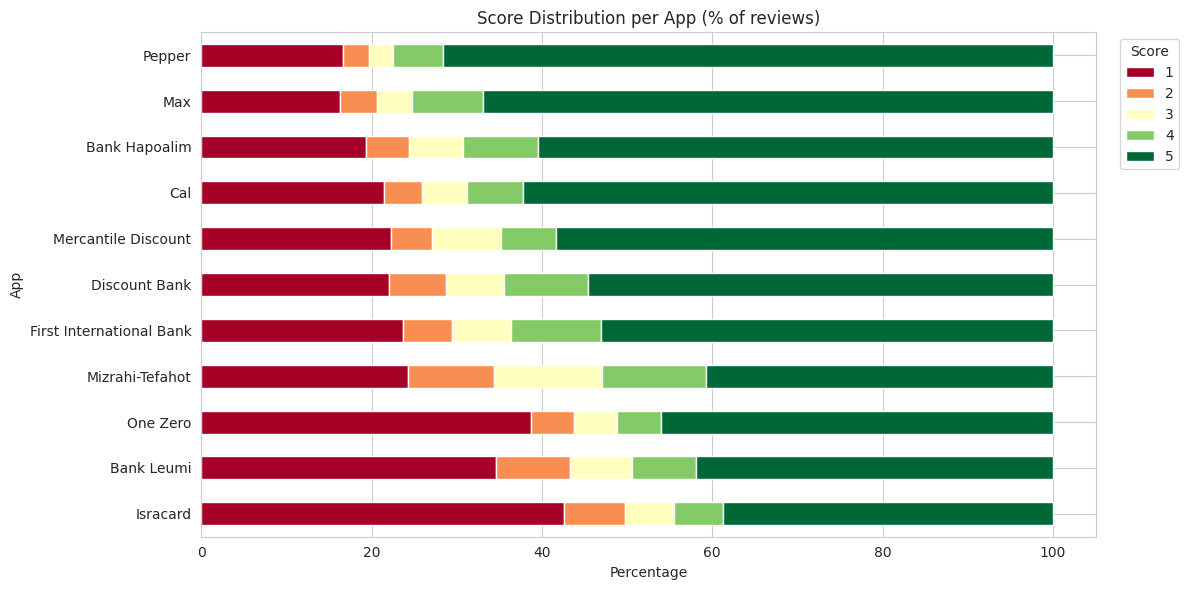

In [3]:
score_dist = reviews.groupby(['name', 'score']).size().unstack(fill_value=0)
score_dist_pct = score_dist.div(score_dist.sum(axis=1), axis=0) * 100

avg_score = reviews.groupby('name')['score'].mean()
score_dist_pct = score_dist_pct.loc[avg_score.sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 6))
score_dist_pct.plot(kind='barh', stacked=True, ax=ax,
                    colormap='RdYlGn', edgecolor='white')
ax.set_title('Score Distribution per App (% of reviews)')
ax.set_xlabel('Percentage')
ax.set_ylabel('App')
ax.legend(title='Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5.2 Time Trends

How do review volume and score evolve over time? Where are the FIBI recovery, Pepper decline, and Isracard April 2023 incident visible?

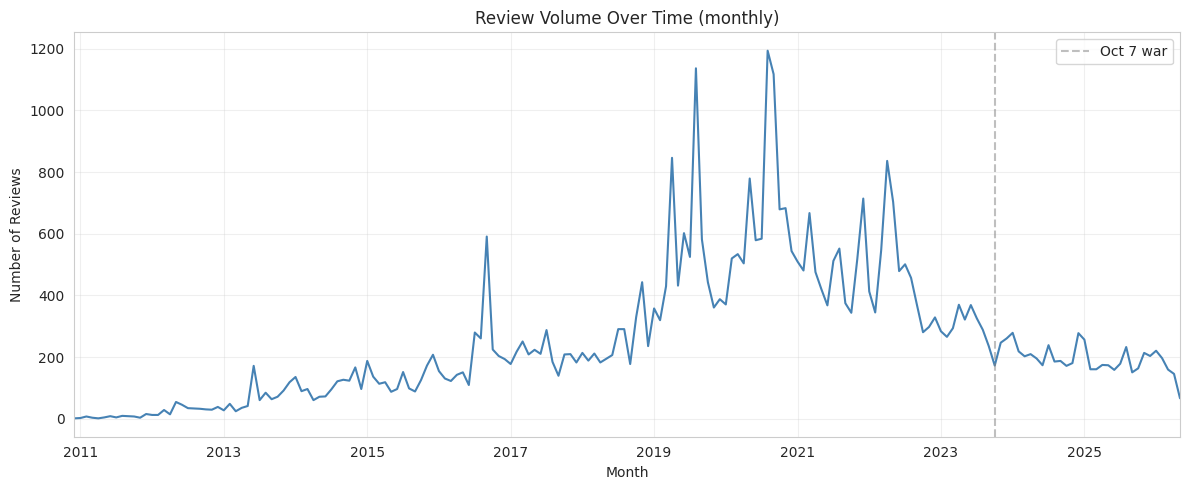

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
monthly_vol = reviews.set_index('review_date').resample('ME').size()
monthly_vol.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Review Volume Over Time (monthly)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.grid(True, alpha=0.3)
ax.axvline(pd.Timestamp('2023-10-07'), color='gray', linestyle='--',
           alpha=0.5, label='Oct 7 war')
ax.legend()
plt.tight_layout()
plt.show()

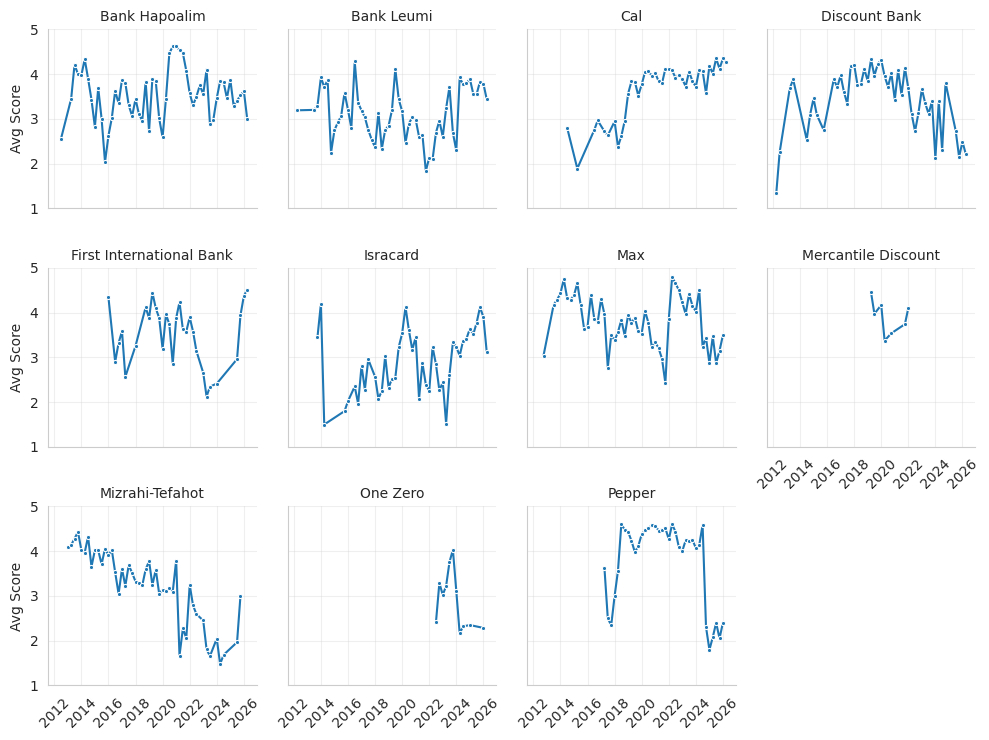

In [5]:
reviews['quarter'] = reviews['review_date'].dt.to_period('Q').dt.start_time
quarterly = reviews.groupby(['name', 'quarter']).agg(
    avg_score=('score', 'mean'),
    n_reviews=('review_id', 'count')
).reset_index()
quarterly = quarterly[quarterly['n_reviews'] >= 20]

g = sns.FacetGrid(quarterly, col='name', col_wrap=4, height=2.5,
                  sharex=True, sharey=True)
g.map_dataframe(sns.lineplot, x='quarter', y='avg_score',
                marker='o', markersize=3, linewidth=1.5)
g.set_titles('{col_name}', size=10)
g.set_axis_labels('', 'Avg Score')
g.set(ylim=(1, 5))
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.3 Topic Patterns

Which topics drive negative reviews? What is each bank's complaint personality?

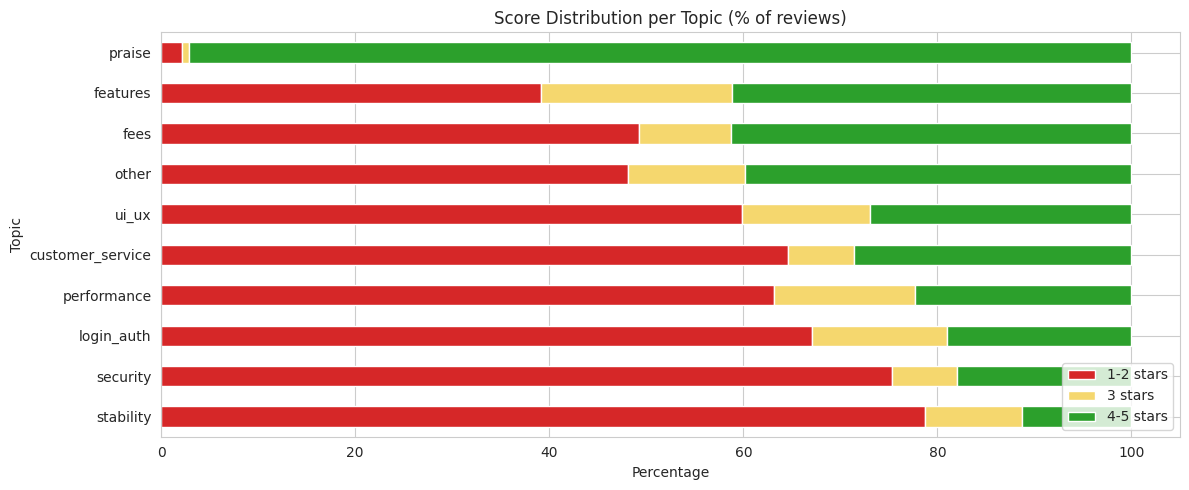

In [6]:
topic_dist = pd.read_sql("""
SELECT 
    rt.topic,
    r.score
FROM review_topics rt
INNER JOIN reviews r ON rt.review_id = r.review_id
WHERE r.score IS NOT NULL
""", engine)

topic_summary = topic_dist.groupby('topic').agg(
    pct_negative=('score', lambda x: (x <= 2).mean() * 100),
    pct_middle=('score', lambda x: ((x > 2) & (x < 4)).mean() * 100),
    pct_positive=('score', lambda x: (x >= 4).mean() * 100),
    avg_score=('score', 'mean')
).reset_index().sort_values('avg_score')

fig, ax = plt.subplots(figsize=(12, 5))
topic_summary.set_index('topic')[['pct_negative', 'pct_middle', 'pct_positive']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#d62728', '#f5d76e', '#2ca02c'])
ax.set_title('Score Distribution per Topic (% of reviews)')
ax.set_xlabel('Percentage')
ax.set_ylabel('Topic')
ax.legend(['1-2 stars', '3 stars', '4-5 stars'], loc='lower right')
plt.tight_layout()
plt.show()

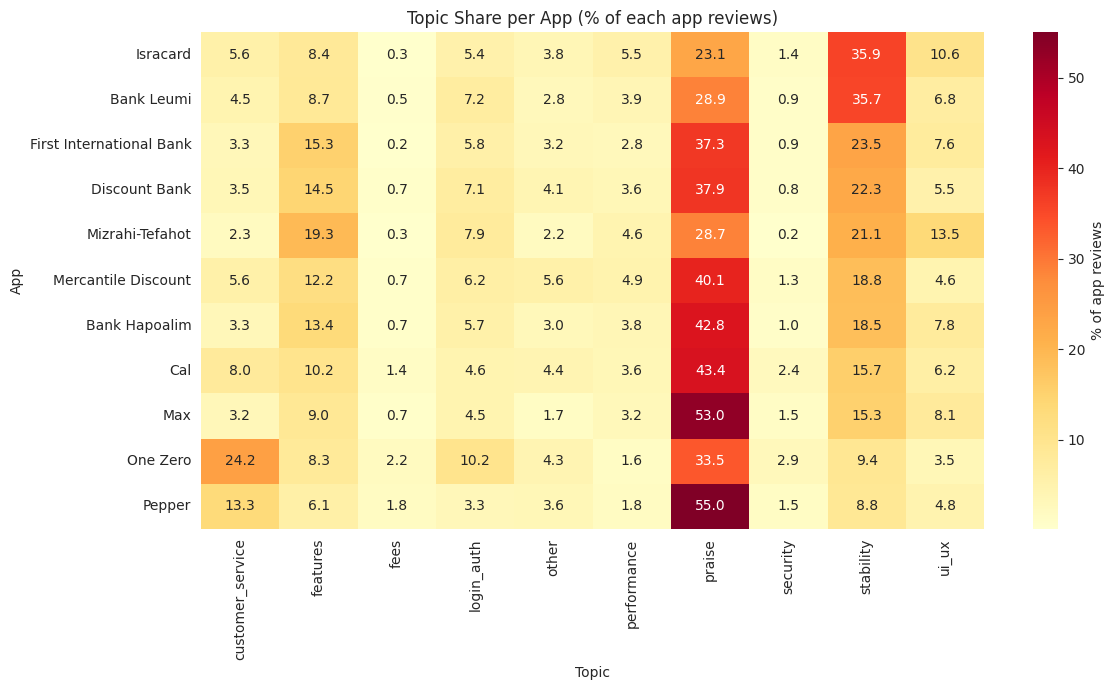

In [7]:
topic_per_app = pd.read_sql("""
SELECT 
    a.name,
    rt.topic
FROM review_topics rt
INNER JOIN reviews r ON rt.review_id = r.review_id
INNER JOIN apps a ON r.app_id = a.app_id
""", engine)

topic_share = pd.crosstab(topic_per_app['name'], topic_per_app['topic'],
                          normalize='index') * 100
topic_share = topic_share.sort_values('stability', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(topic_share, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of app reviews'}, ax=ax)
ax.set_title('Topic Share per App (% of each app reviews)')
ax.set_xlabel('Topic')
ax.set_ylabel('App')
plt.tight_layout()
plt.show()